# predictive_maintenance

参考资料：
https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
path = "predictive_maintenance.csv"
df = pd.read_csv(path)
print(df.shape)                   # (10000, 10)
df.head()

(10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [34]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
categorical_features = ["Type"]

X = df[numeric_features + categorical_features]
y = df['Failure Type']
# 类别分布很不均衡，先看一下
print(y.value_counts())

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64
col_0                         0      1      2      3      4      5
Failure Type                                                      
Heat Dissipation Failure  0.000  0.536  0.000  0.464  0.000  0.000
No Failure                0.168  0.158  0.225  0.169  0.082  0.197
Overstrain Failure        0.000  0.641  0.000  0.000  0.000  0.359
Power Failure             0.000  0.253  0.168  0.147  0.326  0.105
Random Failures           0.056  0.278  0.000  0.333  0.056  0.278
Tool Wear Failure         0.200  0.378  0.000  0.000  0.133  0.289


In [20]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type
0,298.1,308.6,1551,42.8,0,M
1,298.2,308.7,1408,46.3,3,L
2,298.1,308.5,1498,49.4,5,L
3,298.2,308.6,1433,39.5,7,L
4,298.2,308.7,1408,40.0,9,L


## 特征预处理

K-Means 基于欧氏距离。数值特征的量纲不同，因此需要标准化；
`Type` 是类别特征，先用独热编码转换为数值特征。

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_features),
    ]
)
X_scaled = preprocessor.fit_transform(X)

In [26]:
X_scaled

array([[-0.95238944, -0.94735989,  0.06818514, ...,  0.        ,
         0.        ,  1.        ],
       [-0.90239341, -0.879959  , -0.72947151, ...,  0.        ,
         1.        ,  0.        ],
       [-0.95238944, -1.01476077, -0.22744984, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.50242514, -0.94735989,  0.59251888, ...,  0.        ,
         0.        ,  1.        ],
       [-0.50242514, -0.879959  , -0.72947151, ...,  1.        ,
         0.        ,  0.        ],
       [-0.50242514, -0.879959  , -0.2162938 , ...,  0.        ,
         0.        ,  1.        ]])

## K-Means 聚类

真实类别有 6 种，所以先试试 k=6。K-Means 只知道“这是第 0~5 簇”，
簇编号和真实类别名没有任何对应关系，需要用交叉表人工对账。


In [27]:
kmeans = KMeans(n_clusters=6, n_init="auto", random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 交叉表：行 = 真实类别，列 = 聚类簇编号
pd.crosstab(y, clusters, rownames=["真实类别"], colnames=["簇编号"])


簇编号,0,1,2,3,4,5
真实类别,,,,,,
Heat Dissipation Failure,0,60,0,52,0,0
No Failure,1621,1529,2175,1636,791,1900
Overstrain Failure,0,50,0,0,0,28
Power Failure,0,24,16,14,31,10
Random Failures,1,5,0,6,1,5
Tool Wear Failure,9,17,0,0,6,13


## 用真实标签评估聚类效果

虽然训练没用标签，但既然我们有，就可以量化“聚类结构”与“真实类别”
的一致程度（注意：这与分类的准确率不是同一个概念）：

- **ARI（调整兰德指数）**：取值 [-1, 1]，1 表示完全一致，0 为随机水平。
- **同质性（Homogeneity）**：同一簇里的样本是否属于同一真实类别。
- **完整性（Completeness）**：同一真实类别的样本是否被分到同一簇。


In [28]:
print(f"ARI         : {adjusted_rand_score(y, clusters):.3f}")
print(f"同质性 Homog: {homogeneity_score(y, clusters):.3f}")
print(f"完整性 Compl: {completeness_score(y, clusters):.3f}")


ARI         : 0.002
同质性 Homog: 0.138
完整性 Compl: 0.016


输入数据形状：(10000, 8)
前两个主成分解释方差占比：67.7%


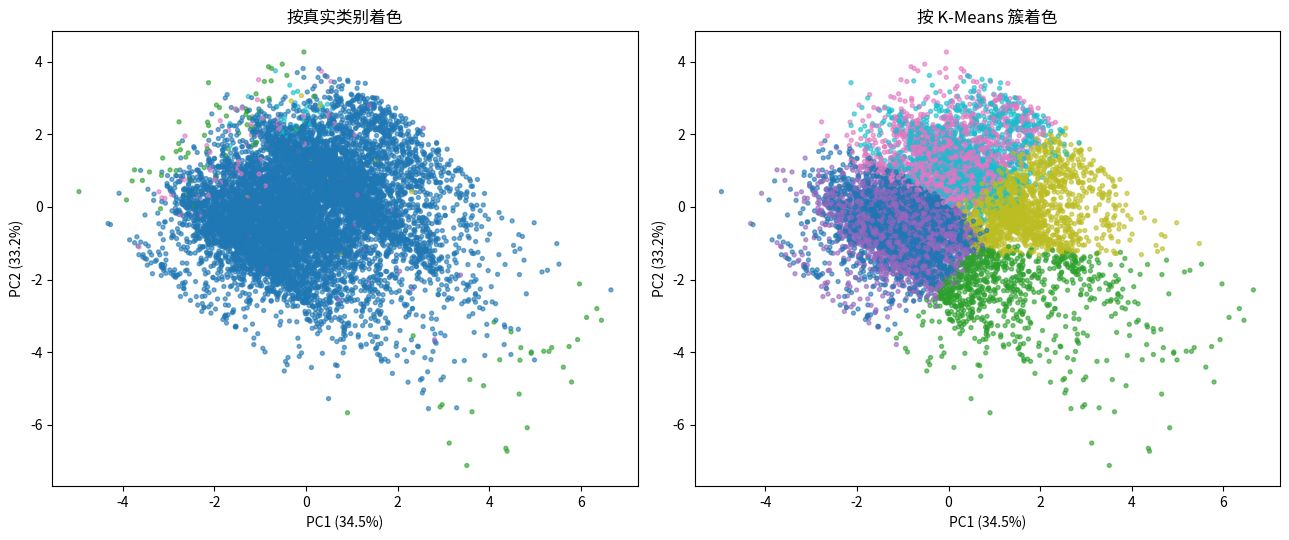

col_0                         0      1      2      3      4      5
Failure Type                                                      
Heat Dissipation Failure  0.000  0.536  0.000  0.464  0.000  0.000
No Failure                0.168  0.158  0.225  0.169  0.082  0.197
Overstrain Failure        0.000  0.641  0.000  0.000  0.000  0.359
Power Failure             0.000  0.253  0.168  0.147  0.326  0.105
Random Failures           0.056  0.278  0.000  0.333  0.056  0.278
Tool Wear Failure         0.200  0.378  0.000  0.000  0.133  0.289


In [35]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"输入数据形状：{X_scaled.shape}")
print(f"前两个主成分解释方差占比：{pca.explained_variance_ratio_.sum():.1%}")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, coloring, title in [
    (axes[0], y, "按真实类别着色"),
    (axes[1], clusters, "按 K-Means 簇着色"),
]:
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=pd.factorize(coloring)[0],
                         s=8, alpha=0.6, cmap="tab10")
    ax.set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
           ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", title=title)
plt.tight_layout()
plt.show()
print(pd.crosstab(y, clusters, normalize="index").round(3))